In [1]:
import numpy as np
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "sst2"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence', 'label', 'idx'],
    num_rows: 67349
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence': 'hide new secretions from the parental units ',
 'label': 0,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence']

"that 's far too tragic to merit such superficial treatment "

In [11]:
raw_train_dataset[5]['label']

0

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence': Value('string'),
 'label': ClassLabel(names=['negative', 'positive']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1821
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 47]),
 'token_type_ids': torch.Size([32, 47]),
 'attention_mask': torch.Size([32, 47])}

# 4. Load Model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.7323, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
teacher_model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
teacher_model.set_use_module_grafting(False)
teacher_model.set_use_scc_status(False)

In [27]:
outputs = teacher_model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.6926, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [28]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
teacher_model.to(device)

device

device(type='cuda')

### Load Trained Weights

In [29]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [30]:
from train_eval_func import eval_loop

In [31]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.9311926605504587}

In [32]:
teacher_model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [33]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.9311926605504587}

# 5. Top Layer Drop

In [34]:
from layer_drop import layer_drop

In [35]:
init_metric = eval_loop(model, val_dataloader, task_name, device)[0]
init_metric

{'accuracy': 0.9311926605504587}

In [36]:
performance_track = layer_drop(
    model, train_dataloader, val_dataloader, task_name, device, init_metric=init_metric, num_merges=9, 
    teacher_model=teacher_model, drop_strategy="top", recovery_epochs=3
)

Target Metric for sst2: accuracy
Original accuracy score: 0.9312
Recovery threshold: 0.0093

Merge Iteration: 1/9
Number of Layers Remaining: 11
  Metrics:
    ★ accuracy: 0.9243
  Performance drop: 0.0069 (threshold: 0.0093)
  → Recovery training NOT needed
  • 11 layers (not in target list, skipping save)
Merge Iteration: 2/9
Number of Layers Remaining: 10
  Metrics:
    ★ accuracy: 0.9128
  Performance drop: 0.0183 (threshold: 0.0093)
  → Recovery training NEEDED
  → Training: 3 epochs, lr=1e-05


Training:   0%|          | 0/6315 [00:00<?, ?it/s]

Knowledge distillation used!


/home/abhinavl/work/Layer_Graft/layer-grafting-publication/drop_layer_strategy/../train_eval_func.py:223: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  total_loss += float(loss)
Training:  33%|███▎      | 2105/6315 [07:10<14:23,  4.87it/s]

✓ Saved checkpoint (best loss: 0.5028)

<----------------- Epoch 1 ----------------->
Loss: 0.11, Training Metrics:
  accuracy: 0.9822
Validation Loss: 0.5, Validation Metrics:
  accuracy: 0.9174
Elapsed Time: 433.1338 sec


...

Training:  67%|██████▋   | 4210/6315 [07:40<04:05,  8.59it/s]  

✓ Saved checkpoint (best loss: 0.8452)

<----------------- Epoch 2 ----------------->
Loss: 0.32, Training Metrics:
  accuracy: 0.9684
Validation Loss: 0.85, Validation Metrics:
  accuracy: 0.8739
Elapsed Time: 228.1249 sec


Training: 100%|██████████| 6315/6315 [11:35<00:00,  9.08it/s]  


<----------------- Epoch 3 ----------------->
Loss: 0.24, Training Metrics:
  accuracy: 0.9741
Validation Loss: 0.87, Validation Metrics:
  accuracy: 0.8704
Elapsed Time: 227.8319 sec

Total Training Time: 695.27 sec
Chosen Primary Metric: accuracy
Best Metric Run: 0.8739

  → Loading best checkpoint...


  ✓ Loaded best checkpoint from epoch 2
    Best val loss: 0.8452
    Best val metrics: {'accuracy': 0.8738532110091743}
  ✓ Cleaned up temporary checkpoint
  ✓ Saved 3-layer model to ./weights/top/layer-3-sst2.pt


In [37]:
performance_track

{'performance_track': [{'accuracy': 0.9311926605504587},
  {'accuracy': 0.9243119266055045},
  {'accuracy': 0.9231651376146789},
  {'accuracy': 0.9208715596330275},
  {'accuracy': 0.9128440366972477},
  {'accuracy': 0.9094036697247706},
  {'accuracy': 0.9048165137614679},
  {'accuracy': 0.9013761467889908},
  {'accuracy': 0.8887614678899083},
  {'accuracy': 0.8738532110091743}],
 'remaining_layers': [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
  [0, 1, 2, 3, 4, 5, 6, 7, 8],
  [0, 1, 2, 3, 4, 5, 6, 7],
  [0, 1, 2, 3, 4, 5, 6],
  [0, 1, 2, 3, 4, 5],
  [0, 1, 2, 3, 4],
  [0, 1, 2, 3],
  [0, 1, 2]]}

In [38]:
torch.save(performance_track, f'./weights/top/performance_track_{task_name}.pt')

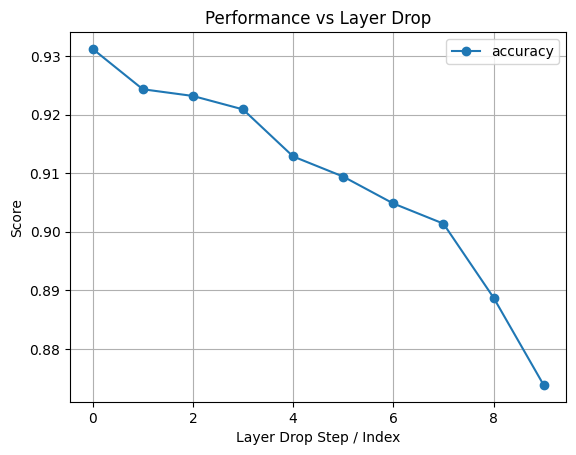

In [39]:
import matplotlib.pyplot as plt

performance_track = performance_track['performance_track']

# get all metric names dynamically
metrics = performance_track[0].keys()

x = list(range(len(performance_track)))  # e.g., layer index or drop step

plt.figure()

for metric in metrics:
    y = [entry.get(metric, None) for entry in performance_track]
    plt.plot(x, y, marker='o', label=metric)

plt.xlabel("Layer Drop Step / Index")
plt.ylabel("Score")
plt.title("Performance vs Layer Drop")
plt.legend()
plt.grid()

plt.show()